In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import datetime
import pandas as pd
import math
from scipy.stats import kde
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp2d
import okada_wrapper
import cutde.halfspace as HS
import cutde.fullspace as FS
import matplotlib.colors as mcolors
import pickle
from scipy.spatial import Delaunay
from functions_cheng_drained import PoroElasModel_HF as PoroElasModel_HF_drained
from functions_cheng_undrained import PoroElasModel_HF as PoroElasModel_HF_undrained
from sklearn.cluster import DBSCAN
from scipy.stats import poisson
from math import comb
from datetime import timedelta

model_drained = PoroElasModel_HF_drained()
model = PoroElasModel_HF_undrained()

In [2]:
## load data_cluster
import pickle
path_ = '/Users/smarty92/Documents/postDoc_Caltech/project/draft_paper/MD/open_research_section/data_clusters.pkl'

file_= open(path_, 'rb')
data_clust = pickle.load(file_)
## load unconvencional production data

path='/Users/smarty92/Documents/postDoc_Caltech/project/EP-Exxon-Mobil-2022/injection_data_2025/fracking/ProdTimeSeries_09112025.pkl'
file_= open(path, 'rb')
data_unconv = pickle.load(file_)
API_unconv = list(data_unconv['API'])

In [3]:
### Here we extract the wells and earthquakes corresponding to the first cluster (sorted by size) identified as HF-related
catalog_ = data_clust['EQs'][0]
wells_ = data_clust['Wells'][0]

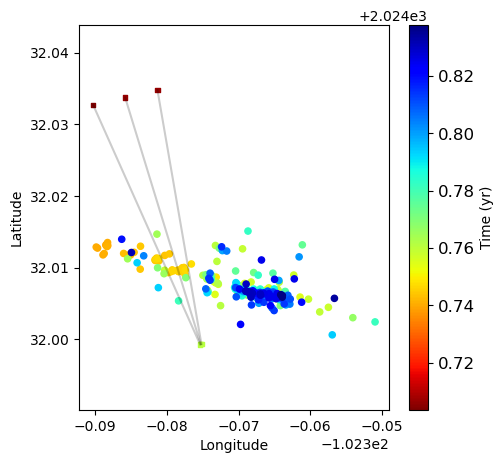

In [4]:
## plot the earhtquakes and the wells
plt.close('all')
eq_time_years = pd.to_datetime(catalog_['datetime']).dt.year.values + pd.to_datetime(catalog_['datetime']).dt.day_of_year.values/365.25 + pd.to_datetime(catalog_['datetime']).dt.hour.values/(24*365.25) ## occurence time -- in yr
inj_start_year =  pd.to_datetime(wells_['JobStartDate']).dt.year.values + pd.to_datetime(wells_['JobStartDate']).dt.day_of_year.values/365.25 ## first day of injection -- in yr
inj_end_year =  pd.to_datetime(wells_['JobEndDate']).dt.year.values + pd.to_datetime(wells_['JobEndDate']).dt.day_of_year.values/365.25 ## last day of injection -- in yr
prod_date = pd.to_datetime(wells_['first_prod_date']).dt.year.values + pd.to_datetime(wells_['first_prod_date']).dt.day_of_year.values/365.25 ## first day of production -- in yr
time_since_inj = (eq_time_years - inj_start_year[0])*365.25 ## 

cmin = np.nanmin(inj_start_year)
cmax = np.nanmax(prod_date)

fig,ax = plt.subplots(figsize = (5,5))
p1 = ax.scatter(catalog_['longitude'],catalog_['latitude'],marker = 'o',c = eq_time_years,s = 20,cmap = 'jet_r',vmin=cmin,vmax = cmax)
x_ = np.array([wells_['SurfLon'],wells_['BotLon']])
y_ = np.array([wells_['SurfLat'],wells_['BotLat']])

ax.plot(x_,y_,'k-',alpha = 0.2)
ax.scatter(x_[0,:],y_[0,:],marker = 's',c = inj_end_year,cmap = 'jet_r',s = 10,vmin=cmin,vmax = cmax)
ax.scatter(x_[1,:],y_[1,:],marker = 's',c = inj_start_year,cmap = 'jet_r',s = 10,vmin=cmin,vmax = cmax)
ax.axis('equal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar  = plt.colorbar(p1)
cbar.set_label('Time (yr)')
cbar.ax.tick_params(labelsize=12)



In [5]:
## Define the hydromechanical parameters
## parameters of the model -- drained regime
density = 2.5e3
shear_modulus = 10e9
poisson_ratio = 0.25
young_modulus = 2*shear_modulus * (1 + poisson_ratio)
bulk_modulus = young_modulus / (3*(1-2*poisson_ratio))
bulk_compressibility = 1 / bulk_modulus
fluid_incompressibility = 1.96e9
fluid_compressibility = 1 / fluid_incompressibility
porosity = 0.08
solid_incompressibility = 37e9
solid_compressibility = 1 / solid_incompressibility
biot_coeff = 1 - (bulk_modulus / solid_incompressibility)
etha = biot_coeff*(1-2*poisson_ratio) / (2*(1-poisson_ratio))
M_inv = ((biot_coeff - porosity) / solid_incompressibility) + (porosity / fluid_incompressibility)
M = 1 / M_inv
permeability = 1e-16
viscosity = 1e-3

## parameter of the odel undrained

undrained_bulk_modulus = bulk_modulus + (biot_coeff**2) * M
poisson_ratio_undrained = (3*undrained_bulk_modulus - 2*shear_modulus) / (2*(3*undrained_bulk_modulus + shear_modulus))
S = (3*undrained_bulk_modulus + 4*shear_modulus) / (M * (3*bulk_modulus + 4*shear_modulus))
diffu = permeability / (viscosity*S)

dict_ = {'poisson_ratio':poisson_ratio_undrained,'shear_modulus':shear_modulus,'diffu':diffu,'S':S,'etha':etha}



In [6]:
## load EQ data

path_df = '/Users/smarty92/Documents/postDoc_Caltech/project/EP-Exxon-Mobil-2022/injection_data_2025/fracking/InjDataPath.csv'
df_hf = pd.read_csv(path_df)

## import df_eq
path_ = '/Users/smarty92/Documents/postDoc_Caltech/project/EP-Exxon-Mobil-2022/catalog_seismicity/MTX_2020_2025_complete.csv'
df_eq = pd.read_csv(path_)
eq_time_years_all = model.datetime_to_years(pd.to_datetime(df_eq['datetime']))
end_catalog_years = np.max(eq_time_years_all)

## import df_eq - unclust

path_ = '/Users/smarty92/Documents/postDoc_Caltech/project/EP-Exxon-Mobil-2022/catalog_seismicity/MTX_2020_2025_complete_unclust.csv'
df_eq_unclust = pd.read_csv(path_)
eq_time_years_all_unclust = model.datetime_to_years(pd.to_datetime(df_eq_unclust['datetime']))
end_catalog_years_unclust = np.max(eq_time_years_all_unclust)

In [7]:
## define the time vector at which stresses and pore-pressurechanges are calculated
vectortime_ = []
step_day = 7 ## time step in days 

tmin = pd.to_datetime(np.min(wells_['JobStartDate'])) 
tmax = np.max(pd.to_datetime(wells_['first_prod_date'])) 
tmax = tmax + datetime.timedelta(days = step_day)

## new eq_family
tmin_years = model.datetime_to_years(tmin)
tmax_years = model.datetime_to_years(tmax) 

startdate_track = tmin

while startdate_track <= tmax:
    
    vectortime_.append(startdate_track)
    startdate_track = startdate_track + datetime.timedelta(days = step_day)
    
vectortime_ = pd.to_datetime(vectortime_,utc=True)

In [8]:
## define grid nodes -- here we define a rectangular 50x50 grid whose limits are defined as the min/max of earthquake longitudes/latitudes extended by 0.05 deg
minlon,minlat = np.nanmin(catalog_['longitude'].values) - 0.05 ,np.nanmin(catalog_['latitude'].values) - 0.05
maxlon,maxlat = np.nanmax(catalog_['longitude'].values) + 0.05,np.nanmax(catalog_['latitude'].values) + 0.05

nodes = 50
veclon_ = np.linspace(minlon,maxlon,nodes)
veclat_ = np.linspace(minlat,maxlat,nodes)
X_,Y_ = np.meshgrid(veclon_,veclat_)
X_flatten,Y_flatten = X_.flatten(),Y_.flatten()
grid_ = np.vstack([X_flatten,Y_flatten]).T

### parameters

depth = np.nanmedian(catalog_['depth (km)'])*1e3 ## depth of the grid that we define as the median of the earthquake depths
number_fracture = 10

flag_hf = model.flag_family_wells(wells_)

In [9]:
## CALCULATE STRESSES AND PORE-PRESSURE FOR DRAINED CONDITIONS

stress_water_undrained = np.zeros([len(grid_),6,len(vectortime_)])
ratio_flowback = 0.2
ratio_proppant = 0.1
width,height = 200,200
for i in range(len(wells_)):

    ind_ = wells_['Unnamed: 0'][i]
    try:
        prod_inj_tmp = model.interp_prod(data_unconv['Month'][ind_], data_unconv['water(l)'][ind_])
    except:
        prod_inj_tmp=(np.array(0),np.array(0))
        
    
    df_sel = wells_.loc[wells_.index[i]]
    stress_water_undrained += model.compute_CS_cheng_undrained(df_sel,grid_,dict_,number_fracture,width,height,vectortime_,depth,prod_inj_tmp,ratio_flowback,ratio_proppant,flag_hf[i])        
    print('For undrained conditions - stress calculation for well : ' + str(i+1) + ' out of ' + str(len(wells_)) )

For undrained conditions - stress calculation for well : 1 out of 3
For undrained conditions - stress calculation for well : 2 out of 3
For undrained conditions - stress calculation for well : 3 out of 3


In [10]:
## CALCULATE STRESSES AND PORE-PRESSURE FOR DRAINED CONDITIONS

stress_water_drained = np.zeros([len(grid_),6,len(vectortime_)])
pore_pressure_ = np.zeros([len(grid_),len(vectortime_)])

for i in range(len(wells_)):

    ind_ = wells_['Unnamed: 0'][i]
    try:
        prod_inj_tmp = model.interp_prod(data_unconv['Month'][ind_], data_unconv['water(l)'][ind_])
    except:
        prod_inj_tmp=(np.array(0),np.array(0))
        
    
    df_sel = wells_.loc[wells_.index[i]]
    stress_water_drained += model_drained.compute_CS_cheng_drained(df_sel,grid_,dict_,number_fracture,width,height,vectortime_,depth,prod_inj_tmp,ratio_flowback,ratio_proppant,flag_hf[i])        
    print('For drained conditions - stress calculation for well : ' + str(i+1) + ' out of ' + str(len(wells_)) )

for i in range(len(wells_)):

    ind_ = wells_['Unnamed: 0'][i]
    try:
        prod_inj_tmp = model.interp_prod(data_unconv['Month'][ind_], data_unconv['water(l)'][ind_])
    except:
        prod_inj_tmp=(np.array(0),np.array(0))
        
    
    df_sel = wells_.loc[wells_.index[i]]
    pore_pressure_ += model_drained.compute_pore_pressure_drained(df_sel,grid_,dict_,number_fracture,width,height,vectortime_,depth,prod_inj_tmp,ratio_flowback,ratio_proppant,flag_hf[i])   
    print('For drained conditions - pore-pressure calculation for well : ' + str(i+1) + ' out of ' + str(len(wells_)) )
 

For drained conditions - stress calculation for well : 1 out of 3
For drained conditions - stress calculation for well : 2 out of 3
For drained conditions - stress calculation for well : 3 out of 3
For drained conditions - pore-pressure calculation for well : 1 out of 3
For drained conditions - pore-pressure calculation for well : 2 out of 3
For drained conditions - pore-pressure calculation for well : 3 out of 3


In [11]:
### DEFINE total stress + pore-pressure
stress_tot = stress_water_undrained + stress_water_drained

In [12]:
## function to compute maximum coulomb stress

def compute_CS(stress_mat,pore_pressure):
    
    max_cs = np.zeros([stress_mat.shape[0],stress_mat.shape[2]])
    mu = 0.6
    
    for i in range(stress_mat.shape[0]):
        for j in range(stress_mat.shape[2]):
    
            vec = stress_mat[i,:,j]
            pp_ = pore_pressure[i,j]

            if np.abs(stress_mat[i,:,j]).sum() > 0:
        
                Stress = np.zeros([3,3])
                Stress[0,0] = vec[0] + pp_                     # Sxx
                Stress[1,1] = vec[1] + pp_                     # Syy
                Stress[2,2] = vec[2] + pp_                      # Szz
                Stress[1,0] = Stress[0,1] = vec[3]   # Sxy
                Stress[2,0] = Stress[0,2] = vec[4]   # Sxz
                Stress[2,1] = Stress[1,2] = vec[5]  # Syz
            
                Stress_maxshear  = 0.5*(np.max(np.linalg.eigvals(np.nan_to_num(Stress)),axis=-1) - np.min(np.linalg.eigvals(np.nan_to_num(Stress)),axis=-1))
                Stress_maxnormal = 0.5*(np.max(np.linalg.eigvals(np.nan_to_num(Stress)),axis=-1) + np.min(np.linalg.eigvals(np.nan_to_num(Stress)),axis=-1))
                Stress_maxcoulomb = (Stress_maxshear - mu*(Stress_maxnormal))
        
                max_cs[i,j] = Stress_maxcoulomb
            else : 
                max_cs[i,j] = 0
                    
     
    return max_cs

In [13]:
## Calculate maximum coulomb stress
max_cs_ = compute_CS(stress_tot,pore_pressure_)

<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
/var/folders/kj/lxqq_3f54x55m7d9pkbmm_z40000gn/T/ipykernel_47755/861563486.py:23: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('$|\Delta Cs_{max}|$ (kPa)')


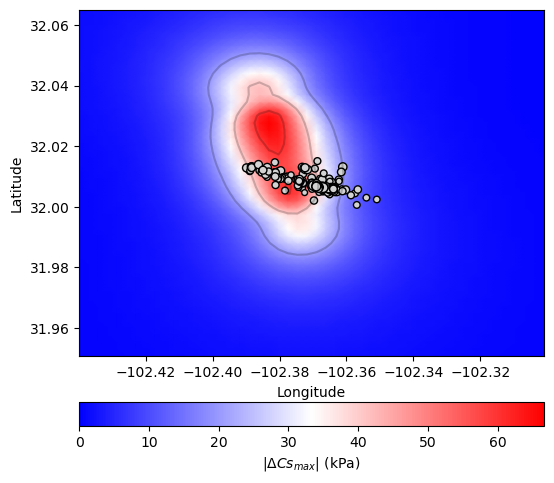

In [14]:
## plotsvarage  maximum Coulomb stress for the last epoch

### plot spatial forecast for the last epoch

fig,ax = plt.subplots(figsize = (6,6))
cmap = 'bwr'
levels = 3

 ## longitude and latitude of the grid nodes
cs_plot = max_cs_.mean(-1).reshape(X_.shape)/1e3 ## coulomb stress
vmax = cs_plot.max()
vmin = 0

p1 = ax.pcolormesh(X_,Y_,cs_plot,cmap = cmap,shading='gouraud',vmin = vmin , vmax = vmax)
ax.contour(X_,Y_,cs_plot,levels = levels,colors = 'k',alpha = 0.2)
ax.scatter(catalog_['longitude'],catalog_['latitude'],marker = 'o',
           s = 20*(2**catalog_['magnitude']),
           c = 'lightgray',
          edgecolors = 'black') ### plot the earthquakes 
ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')
cbar  = plt.colorbar(p1, orientation = 'horizontal', pad=0.1)
cbar.set_label('$|\Delta Cs_{max}|$ (kPa)')


In [15]:
## save as a dict_
path_ = '/Users/smarty92/Documents/postDoc_Caltech/project/draft_paper/MD/processed_data/final_model_results_2500_short/cluster_0_example.pkl'
dict_save = {'stress_':stress_tot[:,:,:len(vectortime_)],'pore_pressure':pore_pressure_[:,:len(vectortime_)],'max_CS':max_cs_[:,:len(vectortime_)],
         'timevector_':vectortime_,'X_':X_, 'Y_':Y_,'familywell':wells_,'catalog':catalog_}
import pickle
with open(path_, 'wb') as f:
    pickle.dump(dict_save, f)